In [31]:
%matplotlib widget

In [32]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
import pygimli as pg
from sklearn.metrics import root_mean_squared_error
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

from FDEM1D import LCModelling, FDEM1D, FDEM1DModelling #, LCModelling, FDEM1D_mdp

from matplotlib.colors import LogNorm
#plt.style.use('bmh')

L = LogNorm(vmin=0.001, vmax=1)
popts = {'norm': L}

In [33]:
m_uc = np.load('models/model_d4_c4_uc.npy')
m_ur = np.load('models/model_d4_c4_ur.npy')

In [34]:
d_uc = []

for m in m_uc:
    d_uc.append(FDEM1D(sgm=m[1:], thk=m[0], height=0.15))

d_uc = np.array(d_uc)

In [35]:
d_ur = []

for m in m_ur:
    d_ur.append(FDEM1D(sgm=m[1:], thk=m[0], height=0.15))

d_ur = np.array(d_ur)

In [36]:
model_ini = m_uc.copy()
model_ini[:,0] = 2.5
model_ini[:,1:] = 0.5

In [37]:
#

# number of layers
nLayers = np.shape(m_uc)[1] -1

# number of measurement positions 
npos = len(d_uc)

LCI = LCModelling(FDEM1DModelling)

data = d_uc.copy()

hw = 0
sw = 0

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_uc_pwi = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_uc_pwi = np.array(m_uc_pwi).reshape(np.shape(m_uc))
d_uc_pwi = np.array(inv.response)
d_uc_pwi = d_uc_pwi.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


16/11/25 - 18:32:04 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f860b350630>


16/11/25 - 18:32:05 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [38]:
#

# number of layers
nLayers = np.shape(m_uc)[1] -1

# number of measurement positions 
npos = len(d_uc)

LCI = LCModelling(FDEM1DModelling)

data = d_uc.copy()

hw = 1
sw = 1

LCI.initJacobian(dataVals=data, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data, nLay=nLayers)
LCI.normalization(data, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
m_uc_lci = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

m_uc_lci = np.array(m_uc_lci).reshape(np.shape(m_uc))
d_uc_lci = np.array(inv.response)
d_uc_lci = d_uc_lci.reshape(np.shape(data))

Inversion is normalized
Jacobian size: 702 117 720


16/11/25 - 18:32:13 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f860c0bcae0>


16/11/25 - 18:32:14 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [39]:
m_uc[:,1:] = m_uc[:,1:] * 1000
m_uc_pwi[:,1:] = m_uc_pwi[:,1:]*1000
m_uc_lci[:,1:] = m_uc_lci[:,1:]*1000

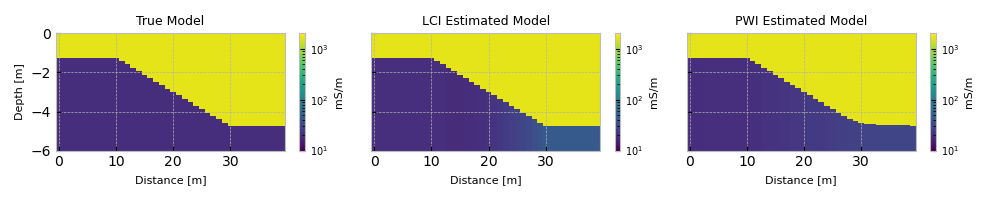

In [40]:
fig, ax = plt.subplots(1,3, sharey = True, figsize=(10,2))

inputs= {'label' : 'mS/m'}

ax[0].set_title('True Model', fontsize=9)
showStitchedModels(m_uc, zMax=6, ax=ax[0], cMin=10, cMax=2000 , **inputs )
ax[1].set_title('LCI Estimated Model', fontsize=9)
showStitchedModels(m_uc_pwi, zMax=6, ax=ax[1], cMin=10, cMax=2000 , **inputs )
ax[2].set_title('PWI Estimated Model', fontsize=9)
ax[2].set_xlabel('Distance [m]', fontsize=8)
ax[1].set_xlabel('Distance [m]', fontsize=8)
ax[0].set_xlabel('Distance [m]', fontsize=8)
ax[0].set_ylabel('Depth [m]', fontsize=8)
#ax[1].set_ylabel('Depth [m]')
#ax[2].set_ylabel('Depth [m]')
showStitchedModels(m_uc_lci, zMax=6, ax=ax[2], cMin=10, cMax=2000 , **inputs )

plt.tight_layout()
plt.savefig('figures/example1Dmod.eps', format='eps')

In [11]:
# Plot data

def PlotDatas(data_true,  data_lci, data_pwi, case='', slope=''):

    fig, ax = plt.subplots(12,3, figsize=(12,12), sharex=True, layout='constrained')

    fs1 = 8
    fs2 = 9  

    # column 1
    ax[0,0].plot(data_true[:,0]*1000, 'r')
  #  ax[0,0].plot(data_1D[:,0]*1000, 'k')
    ax[0,0].plot(data_lci[:,0]*1000, '--b')
    ax[0,0].plot(data_pwi[:,0]*1000, '-.g')
    ax[0,0].set_title('HCP $s=2m$ Quadrature', fontsize=fs2)

    ax[0,1].plot(data_true[:,6]*1000, 'r')
  #  ax[0,1].plot(data_1D[:,6]*1000, 'k')
    ax[0,1].plot(data_lci[:,6]*1000, '--b')
    ax[0,1].plot(data_pwi[:,6]*1000, '-.g')
    ax[0,1].set_title('VCP $s=2m$ Quadrature', fontsize=fs2)

    ax[0,2].plot(data_true[:,3]*1000, 'r')
  #  ax[0,2].plot(data_1D[:,3]*1000, 'k')
    ax[0,2].plot(data_lci[:,3]*1000, '--b')
    ax[0,2].plot(data_pwi[:,3]*1000, '-.g')
    ax[0,2].set_title('PRP $s=2.1m$ Quadrature', fontsize=fs2)

    ax[2,0].plot(data_true[:,9]*1000, 'r')
  #  ax[2,0].plot(data_1D[:,9]*1000, 'k')
    ax[2,0].plot(data_lci[:,9]*1000, '--b')
    ax[2,0].plot(data_pwi[:,9]*1000, '-.g')
    ax[2,0].set_title('HCP $s=2m$ In-Phase', fontsize=fs2)

    ax[2,1].plot(data_true[:,15]*1000, 'r')
  #  ax[2,1].plot(data_1D[:,15]*1000, 'k')
    ax[2,1].plot(data_lci[:,15]*1000, '--b')
    ax[2,1].plot(data_pwi[:,15]*1000, '-.g')
    ax[2,1].set_title('VCP $s=2m$ In-Phase', fontsize=fs2)

    ax[2,2].plot(data_true[:,12]*1000, 'r')
  #  ax[2,2].plot(data_1D[:,12]*1000, 'k')
    ax[2,2].plot(data_lci[:,12]*1000, '--b')
    ax[2,2].plot(data_pwi[:,12]*1000, '-.g')
    ax[2,2].set_title('PRP $s=2.1m$ In-Phase', fontsize=fs2)

    #column 2
  #  ax[1,0].plot(np.abs((data_true[:,0] - data_1D[:,0])/data_true[:,0])*100, 'k')
    ax[1,0].plot(np.abs((data_true[:,0] - data_lci[:,0])/data_true[:,0])*100, '--b')
    ax[1,0].plot(np.abs((data_true[:,0] - data_pwi[:,0])/data_true[:,0])*100, '-.g')
    ax[1,0].set_title('Difference %', fontsize=fs2)

  #  ax[1,1].plot(np.abs((data_true[:,6] - data_1D[:,6])/data_true[:,6])*100, 'k')
    ax[1,1].plot(np.abs((data_true[:,6] - data_lci[:,6])/data_true[:,6])*100, '--b')
    ax[1,1].plot(np.abs((data_true[:,6] - data_pwi[:,6])/data_true[:,6])*100, '-.g')
    ax[1,1].set_title('Difference %', fontsize=fs2)

  #  ax[1,2].plot(np.abs((data_true[:,3] - data_1D[:,3])/data_true[:,3])*100, 'k')
    ax[1,2].plot(np.abs((data_true[:,3] - data_lci[:,3])/data_true[:,3])*100, '--b')
    ax[1,2].plot(np.abs((data_true[:,3] - data_pwi[:,3])/data_true[:,3])*100, '-.g')
    ax[1,2].set_title('Difference %', fontsize=fs2)

  #  ax[3,0].plot(np.abs((data_true[:,9] - data_1D[:,9])/data_true[:,9])*100, 'k')
    ax[3,0].plot(np.abs((data_true[:,9] - data_lci[:,9])/data_true[:,9])*100, '--b')
    ax[3,0].plot(np.abs((data_true[:,9] - data_pwi[:,9])/data_true[:,9])*100, '-.g')
    ax[3,0].set_title('Difference %', fontsize=fs2)

  #  ax[3,1].plot(np.abs((data_true[:,12] - data_1D[:,12])/data_true[:,12])*100, 'k')
    ax[3,1].plot(np.abs((data_true[:,12] - data_lci[:,12])/data_true[:,12])*100, '--b')
    ax[3,1].plot(np.abs((data_true[:,12] - data_pwi[:,12])/data_true[:,12])*100, '-.g')
    ax[3,1].set_title('Difference %', fontsize=fs2)

  #  ax[3,2].plot(np.abs((data_true[:,15] - data_1D[:,15])/data_true[:,15])*100, 'k')
    ax[3,2].plot(np.abs((data_true[:,15] - data_lci[:,15])/data_true[:,15])*100, '--b')
    ax[3,2].plot(np.abs((data_true[:,15] - data_pwi[:,15])/data_true[:,15])*100, '-.g')
    ax[3,2].set_title('Difference %', fontsize=fs2)
    
    # column 3
    ax[4,0].plot(data_true[:,1]*1000, 'r')
#    ax[4,0].plot(data_1D[:,1]*1000, 'k')
    ax[4,0].plot(data_lci[:,1]*1000, '--b')
    ax[4,0].plot(data_pwi[:,1]*1000, '-.g')
    ax[4,0].set_title('HCP $s=4m$ Quadrature', fontsize=fs2)

    ax[4,1].plot(data_true[:,7]*1000, 'r')
 #   ax[4,1].plot(data_1D[:,7]*1000, 'k')
    ax[4,1].plot(data_lci[:,7]*1000, '--b')
    ax[4,1].plot(data_pwi[:,7]*1000, '-.g')
    ax[4,1].set_title('VCP $s=4m$ Quadrature', fontsize=fs2)

    ax[4,2].plot(data_true[:,4]*1000, 'r')
  #  ax[4,2].plot(data_1D[:,4]*1000, 'k')
    ax[4,2].plot(data_lci[:,4]*1000, '--b')
    ax[4,2].plot(data_pwi[:,4]*1000, '-.g')
    ax[4,2].set_title('PRP $s=4.1m$ Quadrature', fontsize=fs2)

    ax[6,0].plot(data_true[:,10]*1000, 'r')
   # ax[6,0].plot(data_1D[:,10]*1000, 'k')
    ax[6,0].plot(data_lci[:,10]*1000, '--b')
    ax[6,0].plot(data_pwi[:,10]*1000, '-.g')
    ax[6,0].set_title('HCP $s=4m$ In-Phase', fontsize=fs2)

    ax[6,1].plot(data_true[:,16]*1000, 'r')
    #ax[6,1].plot(data_1D[:,16]*1000, 'k')
    ax[6,1].plot(data_lci[:,16]*1000, '--b')
    ax[6,1].plot(data_pwi[:,16]*1000, '-.g')
    ax[6,1].set_title('VCP $s=4m$ In-Phase', fontsize=fs2)

    ax[6,2].plot(data_true[:,13]*1000, 'r')
#    ax[6,2].plot(data_1D[:,13]*1000, 'k')
    ax[6,2].plot(data_lci[:,13]*1000, '--b')
    ax[6,2].plot(data_pwi[:,13]*1000, '-.g')
    ax[6,2].set_title('PRP $s=4.1m$ In-Phase', fontsize=fs2)

    #column 4
 #   ax[5,0].plot(np.abs((data_true[:,1] - data_1D[:,1])/data_true[:,1])*100, 'k')
    ax[5,0].plot(np.abs((data_true[:,1] - data_lci[:,1])/data_true[:,1])*100, '--b')
    ax[5,0].plot(np.abs((data_true[:,1] - data_pwi[:,1])/data_true[:,1])*100, '-.g')
    ax[5,0].set_title('Difference %', fontsize=fs2)

  #  ax[5,1].plot(np.abs((data_true[:,7] - data_1D[:,7])/data_true[:,7])*100, 'k')
    ax[5,1].plot(np.abs((data_true[:,7] - data_lci[:,7])/data_true[:,7])*100, '--b')
    ax[5,1].plot(np.abs((data_true[:,7] - data_pwi[:,7])/data_true[:,7])*100, '-.g')
    ax[5,1].set_title('Difference %', fontsize=fs2)

   # ax[5,2].plot(np.abs((data_true[:,4] - data_1D[:,4])/data_true[:,1])*100, 'k')
    ax[5,2].plot(np.abs((data_true[:,4] - data_lci[:,4])/data_true[:,1])*100, '--b')
    ax[5,2].plot(np.abs((data_true[:,4] - data_pwi[:,4])/data_true[:,1])*100, '-.g')
    ax[5,2].set_title('Difference %', fontsize=fs2)

#    ax[7,0].plot(np.abs((data_true[:,10] - data_1D[:,10])/data_true[:,10])*100, 'k')
    ax[7,0].plot(np.abs((data_true[:,10] - data_lci[:,10])/data_true[:,10])*100, '--b')
    ax[7,0].plot(np.abs((data_true[:,10] - data_pwi[:,10])/data_true[:,10])*100, '-.g')
    ax[7,0].set_title('Difference %', fontsize=fs2)

 #   ax[7,1].plot(np.abs((data_true[:,13] - data_1D[:,13])/data_true[:,13])*100, 'k')
    ax[7,1].plot(np.abs((data_true[:,13] - data_lci[:,13])/data_true[:,13])*100, '--b')
    ax[7,1].plot(np.abs((data_true[:,13] - data_pwi[:,13])/data_true[:,13])*100, '-.g')
    ax[7,1].set_title('Difference %', fontsize=fs2)

  #  ax[7,2].plot(np.abs((data_true[:,16] - data_1D[:,16])/data_true[:,16])*100, 'k')
    ax[7,2].plot(np.abs((data_true[:,16] - data_lci[:,16])/data_true[:,16])*100, '--b')
    ax[7,2].plot(np.abs((data_true[:,16] - data_pwi[:,16])/data_true[:,16])*100, '-.g')
    ax[7,2].set_title('Difference %', fontsize=fs2)

    # column 5
    ax[8,0].plot(data_true[:,2]*1000, 'r', label='1D')
   # ax[8,0].plot(data_1D[:,2]*1000, 'k', label = '1D')
    ax[8,0].plot(data_lci[:,2]*1000, '--b', label='LCI')
    ax[8,0].plot(data_pwi[:,2]*1000, '-.g', label='PWI')
    ax[8,0].set_title('HCP $s=8m$ Quadrature', fontsize=fs2)

    ax[8,1].plot(data_true[:,8]*1000, 'r')
    #ax[8,1].plot(data_1D[:,8]*1000, 'k')
    ax[8,1].plot(data_lci[:,8]*1000, '--b')
    ax[8,1].plot(data_pwi[:,8]*1000, '-.g')
    ax[8,1].set_title('VCP $s=8m$ Quadrature', fontsize=fs2)

    ax[8,2].plot(data_true[:,5]*1000, 'r')
#    ax[8,2].plot(data_1D[:,5]*1000, 'k')
    ax[8,2].plot(data_lci[:,5]*1000, '--b')
    ax[8,2].plot(data_pwi[:,5]*1000, '-.g')
    ax[8,2].set_title('PRP $s=8.1m$ Quadrature', fontsize=fs2)

    ax[10,0].plot(data_true[:,11]*1000, 'r')
 #   ax[10,0].plot(data_1D[:,11]*1000, 'k')
    ax[10,0].plot(data_lci[:,11]*1000, '--b')
    ax[10,0].plot(data_pwi[:,11]*1000, '-.g')
    ax[10,0].set_title('HCP $s=8m$ In-Phase', fontsize=fs2)

    ax[10,1].plot(data_true[:,17]*1000, 'r')
  #  ax[10,1].plot(data_1D[:,17]*1000, 'k')
    ax[10,1].plot(data_lci[:,17]*1000, '--b')
    ax[10,1].plot(data_pwi[:,17]*1000, '-.g')
    ax[10,1].set_title('VCP $s=8m$ In-Phase', fontsize=fs2)

    ax[10,2].plot(data_true[:,14]*1000, 'r')
   # ax[10,2].plot(data_1D[:,14]*1000, 'k')
    ax[10,2].plot(data_lci[:,14]*1000, '--b')
    ax[10,2].plot(data_pwi[:,14]*1000, '-.g')
    ax[10,2].set_title('PRP $s=8.1m$ In-Phase', fontsize=fs2)

    #column 6
    x = np.arange(0,40)
    #ax[9,0].plot(np.abs((data_true[:,2] - data_1D[:,2])/data_true[:,2])*100, 'k')
    ax[9,0].plot(np.abs((data_true[:,2] - data_lci[:,2])/data_true[:,2])*100, '--b')
    ax[9,0].plot(np.abs((data_true[:,2] - data_pwi[:,2])/data_true[:,2])*100, '-.g')
    ax[9,0].set_title('Difference %', fontsize=fs2)

#    ax[9,1].plot(np.abs((data_true[:,8] - data_1D[:,8])/data_true[:,8])*100, 'k')
    ax[9,1].plot(np.abs((data_true[:,8] - data_lci[:,8])/data_true[:,8])*100, '--b')
    ax[9,1].plot(np.abs((data_true[:,8] - data_pwi[:,8])/data_true[:,8])*100, '-.g')
    ax[9,1].set_title('Difference %', fontsize=fs2)

 #   ax[9,2].plot(np.abs((data_true[:,5] - data_1D[:,5])/data_true[:,5])*100, 'k')
    ax[9,2].plot(np.abs((data_true[:,5] - data_lci[:,5])/data_true[:,5])*100, '--b')
    ax[9,2].plot(np.abs((data_true[:,5] - data_pwi[:,5])/data_true[:,5])*100, '-.g')
    ax[9,2].set_title('Difference %', fontsize=fs2)

  #  ax[11,0].plot(np.abs((data_true[:,11] - data_1D[:,11])/data_true[:,11])*100, 'k')
    ax[11,0].plot(np.abs((data_true[:,11] - data_lci[:,11])/data_true[:,11])*100, '--b')
    ax[11,0].plot(np.abs((data_true[:,11] - data_pwi[:,11])/data_true[:,11])*100, '-.g')
    ax[11,0].set_title('Difference %', fontsize=fs2)

   # ax[11,1].plot(np.abs((data_true[:,14] - data_1D[:,14])/data_true[:,14])*100, 'k')
    ax[11,1].plot(np.abs((data_true[:,14] - data_lci[:,14])/data_true[:,14])*100, '--b')
    ax[11,1].plot(np.abs((data_true[:,14] - data_pwi[:,14])/data_true[:,14])*100, '-.g')
    ax[11,1].set_title('Difference %', fontsize=fs2)

    #ax[11,2].plot(np.abs((data_true[:,17] - data_1D[:,17])/data_true[:,17])*100, 'k')
    ax[11,2].plot(np.abs((data_true[:,17] - data_lci[:,17])/data_true[:,17])*100, '--b')
    ax[11,2].plot(np.abs((data_true[:,17] - data_pwi[:,17])/data_true[:,17])*100, '-.g')
    ax[11,2].set_title('Difference %', fontsize=fs2)

    ax[0,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[2,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[4,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[6,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[8,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[10,0].set_ylabel('[ppt]', fontsize=fs1)

    ax[11,0].set_xlabel('Distance [m]', fontsize=fs1)
    ax[11,1].set_xlabel('Distance [m]', fontsize=fs1)
    ax[11,2].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,3].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,4].set_xlabel('Distance [m]', fontsize=fs1)
  #  ax[5,5].set_xlabel('Distance [m]', fontsize=fs1)

    h, l = ax[8,0].get_legend_handles_labels()
    ax[0,2].legend(h, l, bbox_to_anchor=(1.01, 1.01), fontsize=fs1)
    
    for a in ax.ravel():
        a.tick_params(labelsize=fs1)

    #fig.suptitle('Data fit')
    plt.show()

In [41]:
def PlotDatas(data_true, data_lci, data_pwi, case='', slope=''):

    fig, ax = plt.subplots(6,6, figsize=(12,6), sharex=True, constrained_layout=True)

    fs1 = 8
    fs2 = 9

    listd = [0, 6, 3, 9, 15, 12]
    listp = [0, 1, 2, 3, 4, 5]
    titles = ['HCP $s=2m$ Quadrature', 'VCP $s=2m$ Quadrature', 'PRP $s=2.1m$ Quadrature', 
              'HCP $s=2m$ In-Phase', 'VCP $s=2m$ In-Phase', 'PRP $s=2.1m$ In-Phase']

    for i in range(6):
        ax[i,0].plot(data_true[:,listd[i]]*1000, 'r', label='1D')
     #   ax[i,0].plot(data_1D[:,listd[i]]*1000, 'k', label='1D')
        ax[i,0].plot(data_lci[:,listd[i]]*1000, '--b', label='LCI')
        ax[i,0].plot(data_pwi[:,listd[i]]*1000, '-.g', label='PWI')
        
      #  error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
      #  error1d_std = np.std(error1d)
      #  ax[i,0].fill_between(np.arange(0,40), data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5, label='SD 1D' )

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,0].fill_between(np.arange(0,40), data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5, label='SD LCI')

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,0].fill_between(np.arange(0,40), data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5, label='SD PWI')
        
        ax[i,0].set_title(titles[i], fontsize=fs2)
    
    #column 2
    styles = ['k', '--b', '-.g']

    for i in range(6):

     #   error_1D = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
     #   error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi =  np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
      #  ax[i,1].plot(error_1D, styles[0])
        ax[i,1].plot(error_lci, styles[1])
        ax[i,1].plot(error_pwi, styles[2])
        ax[i,1].set_title('Error', fontsize=fs2)

    #column 3
    listd = [1, 7, 4, 10, 16, 13]
    titles = ['HCP $s=4m$ Quadrature', 'VCP $s=4m$ Quadrature', 'PRP $s=4.1m$ Quadrature',
              'HCP $s=4m$ In-Phase', 'VCP $s=4m$ In-Phase', 'PRP $s=4.1m$ In-Phase']
    

    for i in range(6):
        ax[i,2].plot(data_true[:,listd[i]]*1000, 'r')
    #    ax[i,2].plot(data_1D[:,listd[i]]*1000, 'k')
        ax[i,2].plot(data_lci[:,listd[i]]*1000, '--b')
        ax[i,2].plot(data_pwi[:,listd[i]]*1000, '-.g')
        
     #   error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
     #   error1d_std = np.std(error1d)
    #    ax[i,2].fill_between(np.arange(0,40), data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5)

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,2].fill_between(np.arange(0,40), data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5)

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,2].fill_between(np.arange(0,40), data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5)
    
        ax[i,2].set_title(titles[i], fontsize=fs2)


    for i in range(6):
        
      #  error_1D = np.abs(data_true[:,listd[i]] - data_1D[:, listd[i]])*1000
      #  error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:,listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi = np.abs(data_true[:,listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
    #    ax[i,3].plot(error_1D, styles[0])
        ax[i,3].plot(error_lci, styles[1])
        ax[i,3].plot(error_pwi, styles[2])
        ax[i,3].set_title('Error', fontsize=fs2)

    # column 5
    listd = [2, 8, 5, 11, 17, 14]
    titles = ['HCP $s=8m$ Quadrature', 'VCP $s=8m$ Quadrature', 'PRP $s=8.1m$ Quadrature',
              'HCP $s=8m$ In-Phase', 'VCP $s=8m$ In-Phase', 'PRP $s=8.1m$ In-Phase']
    
    for i in range(6):
        ax[i,4].plot(data_true[:,listd[i]]*1000, 'r')
     #   ax[i,4].plot(data_1D[:,listd[i]]*1000, 'k')
        ax[i,4].plot(data_lci[:,listd[i]]*1000, '--b')
        ax[i,4].plot(data_pwi[:,listd[i]]*1000, '-.g')
        
     #   error1d = np.abs(data_true[:, listd[i]] - data_1D[:, listd[i]])*1000
     #   error1d_std = np.std(error1d)
     #   ax[i,4].fill_between(np.arange(0,40), data_1D[:, listd[i]]*1000 - error1d_std, data_1D[:, listd[i]]*1000 + error1d_std, color='gray', alpha=0.5)

        errorlc = np.abs(data_true[:, listd[i]] - data_lci[:, listd[i]])*1000
        errorlc_std = np.std(errorlc)
        ax[i,4].fill_between(np.arange(0,40), data_lci[:, listd[i]]*1000 - errorlc_std, data_lci[:, listd[i]]*1000 + errorlc_std, color='lightblue', alpha=0.5)

        errorpw = np.abs(data_true[:, listd[i]] - data_pwi[:, listd[i]])*1000
        errorpw_std = np.std(errorpw)
        ax[i,4].fill_between(np.arange(0,40), data_pwi[:, listd[i]]*1000 - errorpw_std, data_pwi[:, listd[i]]*1000 + errorpw_std, color='lightgreen', alpha=0.5)
    
        ax[i,4].set_title(titles[i], fontsize=fs2)

    #column 6
    for i in range(6):
     #   error_1D = np.abs(data_true[:,listd[i]] - data_1D[:, listd[i]])*1000
     #   error_1D_std = np.std(error_1D)

        error_lci = np.abs(data_true[:,listd[i]] - data_lci[:, listd[i]])*1000
        error_lci_std = np.std(error_lci)

        error_pwi = np.abs(data_true[:,listd[i]] - data_pwi[:, listd[i]])*1000
        error_pwi_std = np.std(error_pwi)
     #   ax[i,5].plot(error_1D, styles[0])
        ax[i,5].plot(error_lci, styles[1])
        ax[i,5].plot(error_pwi, styles[2])
        ax[i,5].set_title('Error', fontsize=fs2)
        
    x = np.arange(0,40)

    ax[0,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[1,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[2,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[3,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[4,0].set_ylabel('[ppt]', fontsize=fs1)
    ax[5,0].set_ylabel('[ppt]', fontsize=fs1)

    ax[5,0].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,1].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,2].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,3].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,4].set_xlabel('Distance [m]', fontsize=fs1)
    ax[5,5].set_xlabel('Distance [m]', fontsize=fs1)

   # h1, l1 = ax[0,4].get_legend_handles_labels()
   # h2, l2 = ax[0,3].get_legend_handles_labels()
    h, l = ax[0,0].get_legend_handles_labels()
  #  plt.subplots_adjust(bottom=0.3)
    fig.legend(h, l, loc='lower center',  fontsize=fs1, ncol=7, bbox_to_anchor=(0.5, -0.05))
    for a in ax.ravel():
        a.tick_params(labelsize=fs1)

  #  fig.suptitle('Data fit of Model '+ case+' 1D')
   # plt.tight_layout()
   # plt.show()

16/11/25 - 18:32:35 - matplotlib.backends.backend_ps - WARNING - The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


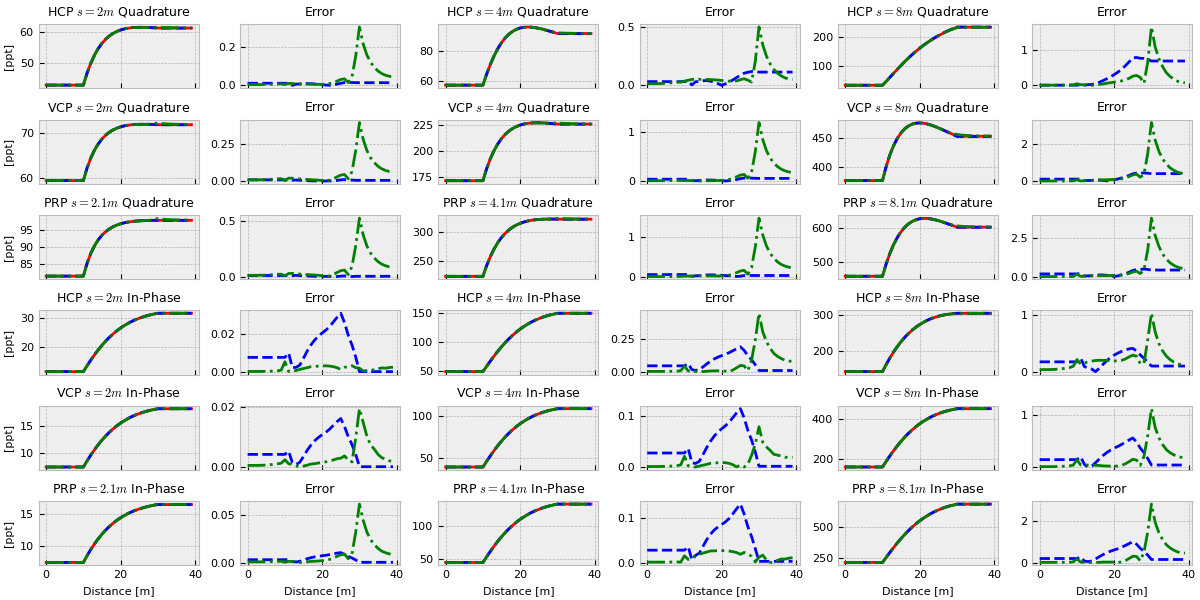

In [42]:
plt.style.use('bmh')

PlotDatas(d_uc, d_uc_pwi, d_uc_lci)
plt.savefig('figures/example1D.eps', format='eps', bbox_inches='tight')